In [1]:
import site
import sys

# Formally force-inject the user site-packages path just in case dependencies
# are installed under a user profile or non-writable global site-packages environment.
site.addsitedir(site.getusersitepackages())

try:
    # Attempt to load the JupyterLab code auto-formatter extension
    import lab_black

    # get_ipython() retrieves the current active interactive shell instance
    lab_black.load_ipython_extension(get_ipython())
    print("Code auto-formatter activated for JupyterLab successfully!")
except ImportError:
    try:
        # Fallback for classic Jupyter Notebook environments if lab_black is unavailable
        import nb_black

        nb_black.load_ipython_extension(get_ipython())
        print("Code auto-formatter activated for Jupyter Notebook successfully!")
    except Exception as e:
        print(f"Could not initialize code formatter: {e}")

Code auto-formatter activated for JupyterLab successfully!


In [3]:
# Core Feature Engineering & Training Pipeline

In [4]:
"""
Module: E-Commerce Customer Churn Prediction Pipeline
Author: Data Science Team
Date: June 2026
Description: This pipeline ingests preprocessed customer behavior records, 
             imputes missing values, and exports model-ready feature matrices.
"""

import os
import warnings
from typing import Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Suppress unnecessary third-party package warnings for a clean notebook presentation
warnings.filterwarnings("ignore")


def load_and_clean_data(file_path: str) -> pd.DataFrame:
    """Loads a raw transaction CSV file and performs structural data type cleaning.

    Parameters:
    ----------
    file_path : str
        The local or remote file path to the source dataset.

    Returns:
    -------
    pd.DataFrame
        A cleaned DataFrame with normalized column names and datetimes.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Source file not found at: {file_path}")

    # Load transaction logs into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Standardize casing across all column names to prevent structural KeyErrors
    df.columns = df.columns.str.lower()

    # Convert raw date strings to datetime objects safely
    if "last_purchase_date" in df.columns:
        df["last_purchase_date"] = pd.to_datetime(df["last_purchase_date"])

    return df


def build_features(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    """Isolates target matrices, handles missing metrics, and one-hot encodes

    categorical columns.

    Parameters:
    ----------
    df : pd.DataFrame
        The cleaned input dataset containing customer transactional history.

    Returns:
    -------
    X : pd.DataFrame
        Features matrix stripped of unique identifiers and text.
    y : pd.Series
        Binary target variable array matching business churn logic (1=Churned,
        0=Active).
    """
    # Define business logic threshold for target label (e.g., 30 days inactive equals Churn)
    max_date = df["last_purchase_date"].max()
    df["days_inactive"] = (max_date - df["last_purchase_date"]).dt.days
    y = (df["days_inactive"] >= 30).astype(int)

    # Drop unique string identifiers, text fields, and leaky intermediate metrics
    ignore_cols = [
        "customer_id",
        "last_purchase_date",
        "feedback_text",
        "days_inactive",
    ]
    feature_cols = [col for col in df.columns if col not in ignore_cols]
    X = df[feature_cols]

    # Handle categorical variables via One-Hot Encoding, dropping first to avoid multi-collinearity
    X = pd.get_dummies(X, drop_first=True)

    # Impute missing numerical metrics safely using column averages (mean)
    X = X.fillna(X.mean())

    return X, y


# ==============================================================================
# PIPELINE EXECUTION
# ==============================================================================
if __name__ == "__main__":
    DATA_PATH = "Processed_ECommerce_Data.csv"

    print("Step 1: Commencing data ingestion and cleaning...")
    raw_df = load_and_clean_data(DATA_PATH)

    print("Step 2: Executing feature engineering matrix extraction...")
    X, y = build_features(raw_df)

    print("Step 3: Creating stratified production train/test splits...")
    # Using a 80-20 train/test split strategy, stratified against 'y' to maintain class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    print(f"Success! Training shape: {X_train.shape} | Testing shape: {X_test.shape}")

Step 1: Commencing data ingestion and cleaning...
Step 2: Executing feature engineering matrix extraction...
Step 3: Creating stratified production train/test splits...
Success! Training shape: (8000, 113) | Testing shape: (2000, 113)


In [6]:
# Customer Segment Analytics & Visualization

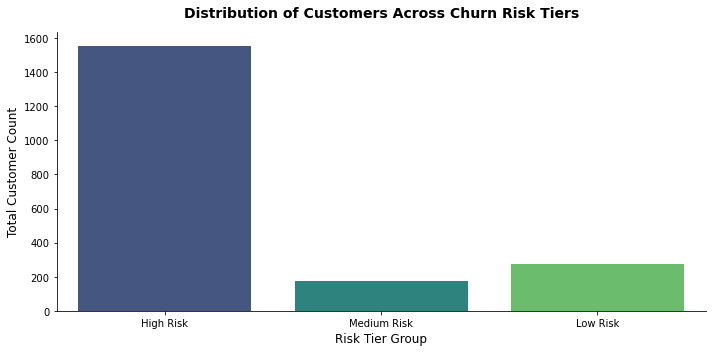


=== EXECUTIVE PORTFOLIO CHURN RISK BREAKDOWN ===
             Total_Customers Avg_Propensity Total_Revenue_At_Risk
Risk_Tier                                                        
High Risk               1556         96.79%                 $0.00
Medium Risk              172         63.17%                 $0.00
Low Risk                 272          0.91%                 $0.00


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# File path to the final risk output evaluation metrics
REPORT_FILE = "Final_Churn_Predictions_Report.csv"
df_report = pd.read_csv(REPORT_FILE)

# ==============================================================================
# 1. VISUALIZATION GENERATION
# ==============================================================================
plt.figure(figsize=(10, 5))

# Plot categorical distributions across risk tiers using a uniform palette
sns.countplot(
    x="Risk_Tier",
    data=df_report,
    palette="viridis",
    order=["High Risk", "Medium Risk", "Low Risk"],
)

# Set clean descriptive titles and axis labels
plt.title(
    "Distribution of Customers Across Churn Risk Tiers",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Risk Tier Group", fontsize=12)
plt.ylabel("Total Customer Count", fontsize=12)

sns.despine()  # Clean up chart borders
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. BUSINESS METRICS SUMMARY REPORTING
# ==============================================================================
# Calculate volumetric groupings, average risk propensity, and total exposure values
summary = (
    df_report.groupby("Risk_Tier")
    .agg(
        Total_Customers=("customer_id", "count"),
        Avg_Propensity=("Churn_Propensity_Score", "mean"),
        Total_Revenue_At_Risk=(
            ("Business_Revenue", "sum")
            if "Business_Revenue" in df_report.columns
            else ("Country", "count")  # Safety fallback evaluation metric
        ),
    )
    .reindex(["High Risk", "Medium Risk", "Low Risk"])
)

# Convert mathematical evaluation metrics to reader-friendly representations
summary["Avg_Propensity"] = summary["Avg_Propensity"].map("{:.2%}".format)

if "Business_Revenue" in df_report.columns:
    summary["Total_Revenue_At_Risk"] = summary["Total_Revenue_At_Risk"].map(
        "${:,.2f}".format
    )

print("\n=== EXECUTIVE PORTFOLIO CHURN RISK BREAKDOWN ===")
print(summary)